In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("naturalNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
system_labels = [r"rhTRIM5$\alpha$",r"huTRIM5$\alpha$",r"huTRIM5$\alpha^{R332P}$"]

systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)
    
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)
    
alignedprotein=[]
alignedproteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and resid 0:1000"))
        sub2.append("protein and resid 0:1000")
        
    alignedprotein.append(sub)
    alignedproteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

In [3]:
def getRMSF(systems,datasets,selection_strings,EQPOINT=250):
    allrmsfs=[]
    rmsfs=[]
    stderrs=[]
    for i in range(len(datasets)):
        subrmsfs = []
        for j in range(len(datasets[i])):
            
            prealigner = align.AlignTraj(systems[i][j],systems[i][j], select=selection_strings[i][j], in_memory=True).run()
            reference_coordinates = systems[i][j].trajectory.timeseries(asel=datasets[i][j]).mean(axis=1)
            reference = mda.Merge(datasets[i][j]).load_new(reference_coordinates[:, None, :], order="afc")
            aligner = align.AlignTraj(systems[i][j], reference, select=selection_strings[i][j], in_memory=True).run()
            
            R = MDAnalysis.analysis.rms.RMSF(datasets[i][j])
            R.run(start=EQPOINT)
            
            subrmsfs.append(R.rmsf)
        allrmsfs.append(subrmsfs)
        #rmsfs.append(mean(subrmsfs,axis = 0))
        #stderrs.append(scipy.stats.sem(subrmsfs,axis = 0))


    return allrmsfs#rmsfs,stderrs

def GetResSlices(topology,trajectory):
    u = mda.Universe(topology,trajectory)
    protein = u.select_atoms("protein")
    resslices=[0]
    t=0
    for i in range(len(protein.residues)):
        t+=len(protein.residues[i].atoms.select_atoms("protein"))
        resslices.append(t)
    return resslices
def GetResSlicesU(sel):
    protein = sel.select_atoms("protein")
    resslices=[0]
    t=0
    for i in range(len(protein.residues)):
        t+=len(protein.residues[i].atoms.select_atoms("protein"))
        resslices.append(t)
    return resslices
def atoms_to_residues(datalist,res_slice_list):
    
    newdatalist=[]
    for j in range(len(datalist)):
        newdata=[]
        for i in range(len(res_slice_list[j])-1):
            newdata.append(mean(datalist[j][res_slice_list[j][i]:res_slice_list[j][i+1]]))
        newdatalist.append(newdata)
    return newdatalist


res_slices=[]
for i in range(len(v1s)):
    res_slices.append(GetResSlicesU(v1s[i][0]))
    
    
allrmsfs=getRMSF(systems,v1s,v1strings,EQPOINT=EQPOINT)



C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\MDAnalysis\analysis\rms.py:877: DeprecationWarning: The `rmsf` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


In [4]:
allrmsfs_residue=[]


for i in range(len(allrmsfs)):
    allrmsfs_system=[]
    for j in range(len(allrmsfs[i])):
        allrmsfs_trj=[]
        for k in range(len(res_slices[i])-1):
            allrmsfs_trj.append(mean(allrmsfs[i][j][res_slices[i][k]:res_slices[i][k+1]]))
        allrmsfs_system.append(allrmsfs_trj)
    allrmsfs_residue.append(allrmsfs_system)
    


In [5]:
for i in range(len(systems)):
    save(system_names[i]+"rmsf-v1-only.npy",allrmsfs_residue[i])

In [6]:
allrmsfs_residue=[]
for i in range(len(systems)):
    allrmsfs_residue.append(load(system_names[i]+"rmsf-v1-only.npy"))

(0.0, 7.0)

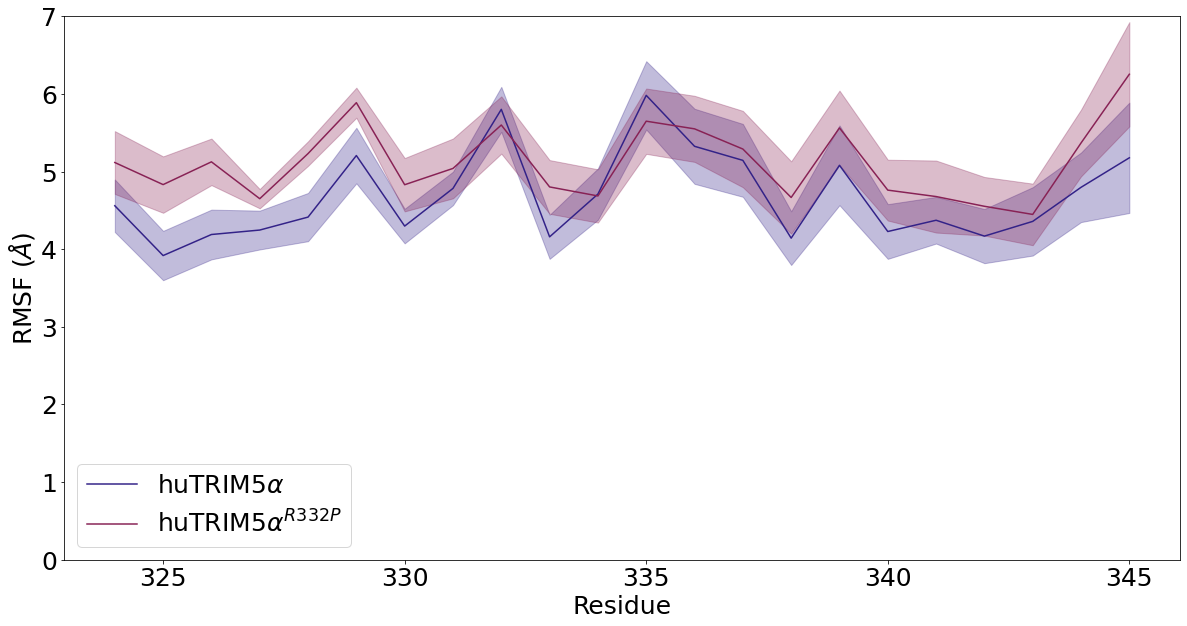

In [7]:
#allrmsfs_residue=load("allrmsfs_residue.npy",allow_pickle = True)
            
    
system_avg=[]
system_sem=[]

for i in range(len(allrmsfs_residue)):
    system_avg.append(mean(allrmsfs_residue[i],axis = 0))
    system_sem.append(scipy.stats.sem(allrmsfs_residue[i],axis = 0))
    
#def insertMyNans(huArray,indices):
#    huList = list(huArray)
#    # Note, index list should be in descending order, otherwise there will be problems 
#    # (since the index of later indexes will increase every time you make an insertion)
#    for i in range(len(indices)):
#        huList.insert(indices[i],nan)
#    return array(huList)
#
#for i in range(1,len(system_avg)):
#    system_avg[i] = insertMyNans(system_avg[i],indices = [338-290,338-290])
#    system_sem[i] = insertMyNans(system_sem[i],indices = [338-290,338-290])
    
    
    
rhresids = arange(291,495)
huresids = systems[1][0].select_atoms("protein").residues.resids
figure(figsize = (20,10))
#plot(rhresids,system_avg[0],color = colourScheme[0],label = system_names[0])
plot(arange(324,346),system_avg[1],color = colourScheme[1],label = system_labels[1])
plot(arange(324,346),system_avg[2],color = colourScheme[2],label = system_labels[2])
    
#fill_between(arange(324,346), system_avg[0] - system_sem[0],system_avg[0] + system_sem[0],color = colourScheme[0],alpha = 0.3)
fill_between(arange(324,346), system_avg[1] - system_sem[1],system_avg[1] + system_sem[1],color = colourScheme[1],alpha = 0.3)
fill_between(arange(324,346), system_avg[2] - system_sem[2],system_avg[2] + system_sem[2],color = colourScheme[2],alpha = 0.3)


xlabel("Residue",fontsize = 25)
ylabel("RMSF ($\AA$)",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

#axvline(415,alpha = 0.1)
#xlim(400,440)
ylim(0,7)
#xlim(324,346)

In [8]:
system_avg[1]

array([4.55914766, 3.91775157, 4.18885959, 4.24622991, 4.41312839,
       5.20565482, 4.29736974, 4.78246519, 5.80038647, 4.15875872,
       4.70953539, 5.98068653, 5.32471816, 5.14363979, 4.1418707 ,
       5.08017614, 4.2273254 , 4.3725441 , 4.16817185, 4.35784228,
       4.79660146, 5.17671621])